In [1]:
import os
clust_list = os.listdir("./ttclust_RMSD/PDBs")
clust_name_list = [name.split(".")[0] for name in clust_list]
clust_name_list.sort()
clust_sys_list = [name.split("-")[0] for name in clust_name_list]
clust_frameNdx_list = [int(name.split("-")[-1][1:]) for name in clust_name_list]
import pandas as pd
ttinfo_df = pd.DataFrame(
    {
        "fileName": clust_name_list,
        "type": clust_sys_list,
        "frameNdx": clust_frameNdx_list
    }
)
ttinfo_df

,fileName,type,frameNdx
0,PAC5-Rep1-C1-f287,PAC5,287
1,PAC5-Rep1-C2-f51,PAC5,51
2,PAC5-Rep1-C3-f947,PAC5,947
3,PAC5-Rep2-C1-f39,PAC5,39
4,PAC5-Rep2-C2-f446,PAC5,446
5,PAC5-Rep2-C3-f830,PAC5,830
6,PAC5-Rep3-C1-f624,PAC5,624
7,PAC5-Rep3-C2-f3203,PAC5,3203
8,PAC5-Rep3-C3-f4063,PAC5,4063
9,PAC5-Rep3-C4-f2061,PAC5,2061


In [2]:
import pickle
import pandas as pd
PAC5_ttFrame = [
    [287, 51, 947],
    [39, 446, 830],
    [624, 3203, 4063, 2061]
    ]
# 0	PAC5-Rep1-C1-f287	PAC5	287
# 1	PAC5-Rep1-C2-f51	PAC5	51
# 2	PAC5-Rep1-C3-f947	PAC5	947
# 3	PAC5-Rep2-C1-f39	PAC5	39
# 4	PAC5-Rep2-C2-f446	PAC5	446
# 5	PAC5-Rep2-C3-f830	PAC5	830
# 6	PAC5-Rep3-C1-f624	PAC5	624
# 7	PAC5-Rep3-C2-f3203	PAC5	3203
# 8	PAC5-Rep3-C3-f4063	PAC5	4063
# 9	PAC5-Rep3-C4-f2061	PAC5	2061

RNA_ttFrame = [
    [282, 905, 335],
    [40, 280, 505, 728],
    [58, 884, 4025, 2953]
    ]
# 10	RNA-Rep1-C1-f282	RNA	282
# 11	RNA-Rep1-C2-f905	RNA	905
# 12	RNA-Rep1-C3-f335	RNA	335
# 13	RNA-Rep2-C1-f40	    RNA	40
# 14	RNA-Rep2-C2-f280	RNA	280
# 15	RNA-Rep2-C3-f505	RNA	505
# 16	RNA-Rep2-C4-f728	RNA	728
# 17	RNA-Rep3-C1-f58	    RNA	58
# 18	RNA-Rep3-C2-f884	RNA	884
# 19	RNA-Rep3-C3-f4025	RNA	4025
# 20	RNA-Rep3-C4-f2953	RNA	2953

ssDNA_ttFrame = [
    [60, 200, 368, 395],
    [56, 168, 304, 514, 792],
    [182, 867, 4710]
    ]
# 21	ssDNA-Rep1-C1-f60	ssDNA	60
# 22	ssDNA-Rep1-C2-f200	ssDNA	200
# 23	ssDNA-Rep1-C3-f368	ssDNA	368
# 24	ssDNA-Rep1-C4-f395	ssDNA	395
# 25	ssDNA-Rep2-C1-f56	ssDNA	56
# 26	ssDNA-Rep2-C2-f168	ssDNA	168
# 27	ssDNA-Rep2-C3-f304	ssDNA	304
# 28	ssDNA-Rep2-C4-f514	ssDNA	514
# 29	ssDNA-Rep2-C5-f792	ssDNA	792
# 30	ssDNA-Rep3-C1-f182	ssDNA	182
# 31	ssDNA-Rep3-C2-f867	ssDNA	867
# 32	ssDNA-Rep3-C3-f4710	ssDNA	4710

def get_disData(path, ttFrame, name, rep):
    with open(path, "rb") as disFile:
        dis = pickle.load(disFile)
    dis = dis.iloc[ttFrame]
    dis["frameNdx"] = name
    dis["Rep"] = rep
    return dis

dis_dic = {
    "PAC5_rep_1": get_disData("../../PAC5_100_1/10_contact/con_results.pkl", PAC5_ttFrame[0], "PAC5", "1"),
    "PAC5_rep_2": get_disData("../../PAC5_100_2/10_contact/con_results.pkl", PAC5_ttFrame[1], "PAC5", "2"),
    "PAC5_rep_3": get_disData("../../PAC5_500_3/10_contact/con_results.pkl", PAC5_ttFrame[2], "PAC5", "3"),
    "RNA_rep_1": get_disData("../../RNA_100_1/10_contact/con_results.pkl", RNA_ttFrame[0], "RNA", "1"),
    "RNA_rep_2": get_disData("../../RNA_100_2/10_contact/con_results.pkl", RNA_ttFrame[1], "RNA", "2"),
    "RNA_rep_3": get_disData("../../RNA_500_3/10_contact/con_results.pkl", RNA_ttFrame[2], "RNA", "3"),
    "ssDNA_rep_1": get_disData("../../ssDNA_100_1/10_contact/con_results.pkl", ssDNA_ttFrame[0], "ssDNA", "1"),
    "ssDNA_rep_2": get_disData("../../ssDNA_100_2/10_contact/con_results.pkl", ssDNA_ttFrame[1], "ssDNA", "2"),
    "ssDNA_rep_3": get_disData("../../ssDNA_500_3/10_contact/con_results.pkl", ssDNA_ttFrame[2], "ssDNA", "3")
}

In [3]:
import pandas as pd
ttclustDisMapDat = pd.concat([df[1] for df in list(dis_dic.items())], axis=0)
ttclustDisMapDat = ttclustDisMapDat.iloc[:, list(range(101)) + [-2, -1]]
ttclustDisMapDat["ndx"] = ttclustDisMapDat.index
ttclustDisMapDat["frameNdx"] = ttclustDisMapDat["ndx"].astype(int)
ttclustDisMapDat = ttclustDisMapDat.iloc[:, list(range(101)) + [-3]]
ttclustDisMapDat

,15,16,17,18,19,20,21,22,23,24,...,107,108,109,110,111,112,113,114,115,frameNdx
287,17.323,14.903,9.951,10.667,4.761,10.196,12.915,7.558,12.355,8.828,...,6.137,2.862,9.531,11.818,15.604,19.204,19.641,19.369,20.142,287
51,12.841,10.971,8.369,4.834,2.301,8.276,9.068,4.395,5.359,2.265,...,4.303,2.015,4.533,4.544,7.863,11.629,13.254,16.094,17.607,51
947,18.421,15.018,12.615,10.282,4.581,9.584,10.391,6.366,6.524,2.280,...,7.428,6.600,11.408,11.536,15.008,18.411,18.915,17.236,19.769,947
39,15.777,13.101,10.216,7.227,2.899,8.772,9.761,4.821,8.872,2.428,...,7.104,2.219,9.197,10.069,13.978,17.255,17.999,16.490,18.486,39
446,11.828,13.056,9.864,7.451,5.185,7.568,7.780,2.402,6.392,2.225,...,6.351,3.110,7.062,8.602,11.608,15.386,17.116,16.939,18.280,446
830,6.453,8.048,6.944,3.061,2.348,6.207,6.989,2.454,6.532,2.182,...,4.699,1.979,6.920,6.046,11.030,14.864,15.835,16.110,17.611,830
624,13.591,10.673,7.848,5.315,1.906,5.592,5.613,2.333,3.257,2.286,...,5.191,2.462,6.187,8.109,10.825,14.688,15.175,14.501,16.390,624
3203,14.396,15.618,12.546,9.645,5.910,10.200,10.251,5.428,6.454,2.327,...,5.236,2.182,6.628,8.498,11.700,15.836,15.503,14.647,16.330,3203
4063,13.582,14.848,12.119,8.770,5.879,10.518,9.575,3.799,5.548,2.157,...,3.199,2.104,5.985,7.975,11.310,15.228,15.727,14.069,16.876,4063
2061,12.421,11.780,8.570,6.018,3.056,6.049,6.322,2.451,3.607,2.198,...,6.861,2.462,6.917,8.383,11.331,15.232,15.832,14.461,17.405,2061


In [7]:
ttclustDisMapDat = pd.merge(ttclustDisMapDat, ttinfo_df, on='frameNdx', how="inner")
ttclustDisMapDat

,15,16,17,18,19,20,21,22,23,24,...,109,110,111,112,113,114,115,frameNdx,fileName,type
0,17.323,14.903,9.951,10.667,4.761,10.196,12.915,7.558,12.355,8.828,...,9.531,11.818,15.604,19.204,19.641,19.369,20.142,287,PAC5-Rep1-C1-f287,PAC5
1,12.841,10.971,8.369,4.834,2.301,8.276,9.068,4.395,5.359,2.265,...,4.533,4.544,7.863,11.629,13.254,16.094,17.607,51,PAC5-Rep1-C2-f51,PAC5
2,18.421,15.018,12.615,10.282,4.581,9.584,10.391,6.366,6.524,2.280,...,11.408,11.536,15.008,18.411,18.915,17.236,19.769,947,PAC5-Rep1-C3-f947,PAC5
3,15.777,13.101,10.216,7.227,2.899,8.772,9.761,4.821,8.872,2.428,...,9.197,10.069,13.978,17.255,17.999,16.490,18.486,39,PAC5-Rep2-C1-f39,PAC5
4,11.828,13.056,9.864,7.451,5.185,7.568,7.780,2.402,6.392,2.225,...,7.062,8.602,11.608,15.386,17.116,16.939,18.280,446,PAC5-Rep2-C2-f446,PAC5
5,6.453,8.048,6.944,3.061,2.348,6.207,6.989,2.454,6.532,2.182,...,6.920,6.046,11.030,14.864,15.835,16.110,17.611,830,PAC5-Rep2-C3-f830,PAC5
6,13.591,10.673,7.848,5.315,1.906,5.592,5.613,2.333,3.257,2.286,...,6.187,8.109,10.825,14.688,15.175,14.501,16.390,624,PAC5-Rep3-C1-f624,PAC5
7,14.396,15.618,12.546,9.645,5.910,10.200,10.251,5.428,6.454,2.327,...,6.628,8.498,11.700,15.836,15.503,14.647,16.330,3203,PAC5-Rep3-C2-f3203,PAC5
8,13.582,14.848,12.119,8.770,5.879,10.518,9.575,3.799,5.548,2.157,...,5.985,7.975,11.310,15.228,15.727,14.069,16.876,4063,PAC5-Rep3-C3-f4063,PAC5
9,12.421,11.780,8.570,6.018,3.056,6.049,6.322,2.451,3.607,2.198,...,6.917,8.383,11.331,15.232,15.832,14.461,17.405,2061,PAC5-Rep3-C4-f2061,PAC5


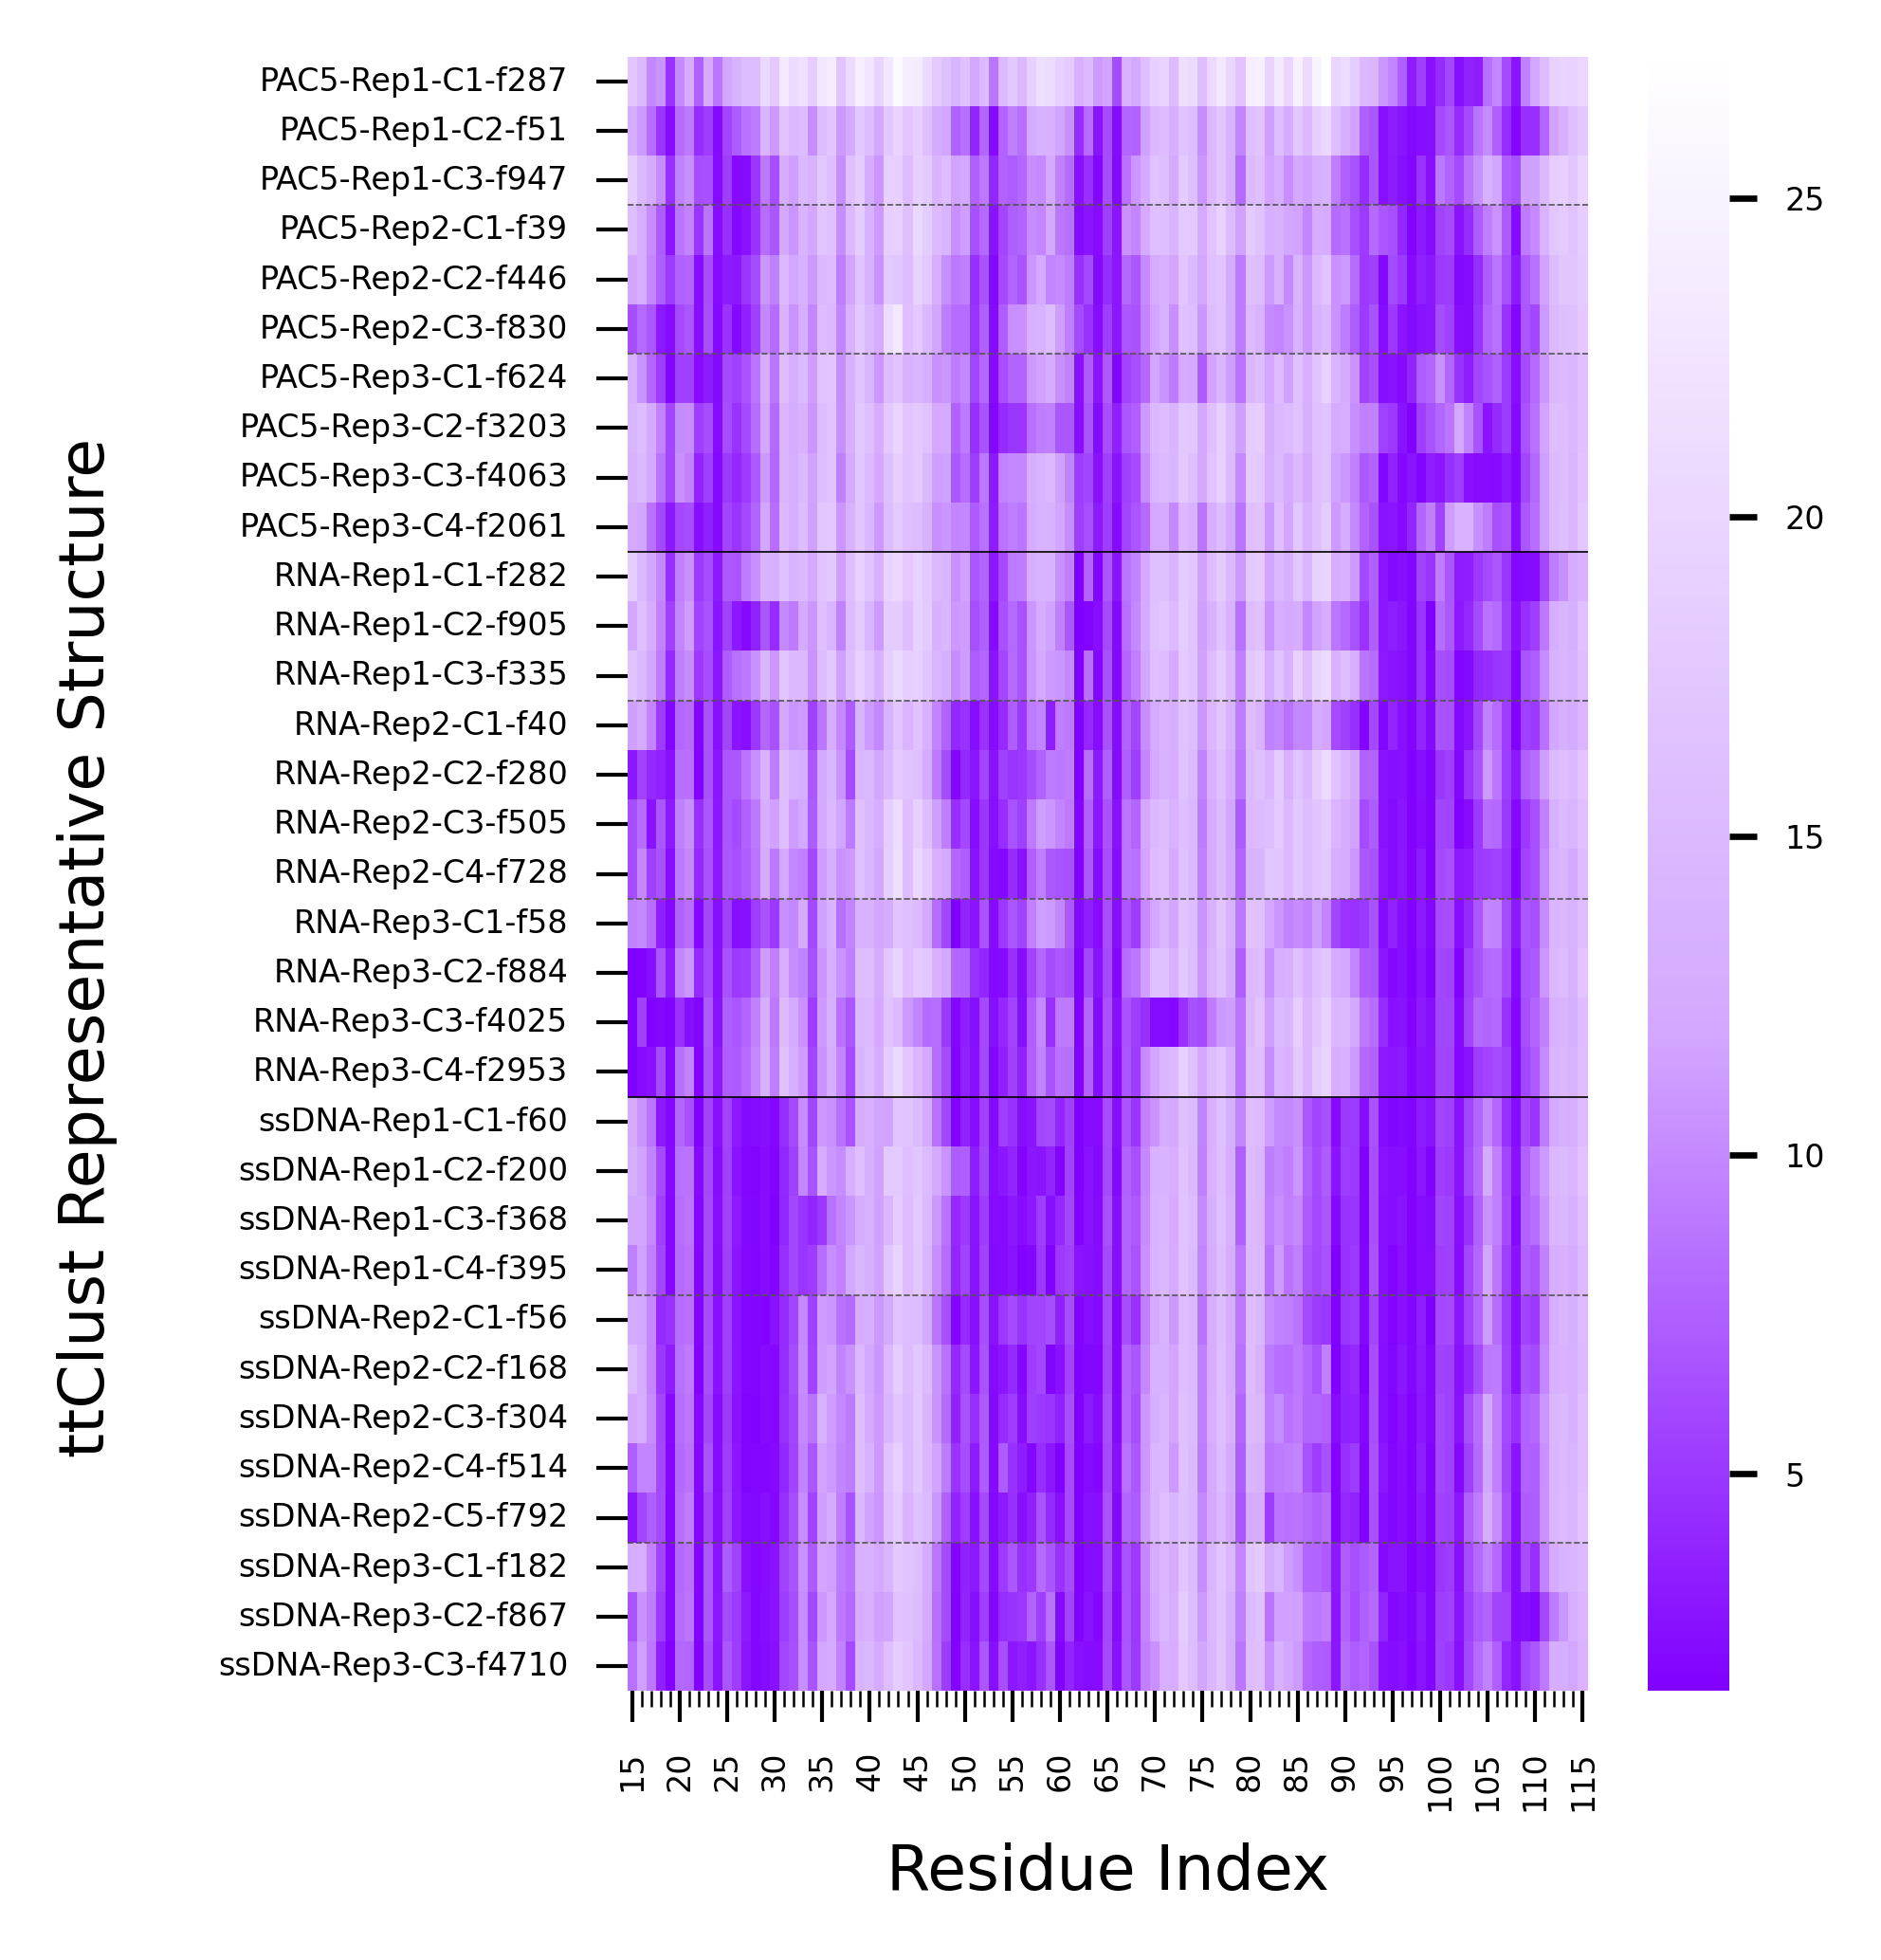

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator

df = ttclustDisMapDat.iloc[:, 0:101]
cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0, "#8000FF"), (0.4, "#D3A7FF"), (1, "#ffffff")],
    N=512
)

# 绘制热图
fig, ax = plt.subplots(figsize=(4.0, 3.5), dpi= 600)  # 设置图形大小
sns.heatmap(df, annot=False, cmap=cmap)#, norm=norm, fmt=".1f", cbar_kws=cbar_kws)  # 设置颜色条的标签
plt.xticks([x+0.5 for x in range(0, 101, 5)], range(15, 116, 5))
plt.yticks([x+0.5 for x in range(0,33)],ttclustDisMapDat["fileName"])
ax.tick_params(axis="x",reset=True, which="both", direction="out", width=0.5, length=4,labelsize=4,right=False,top=False,rotation=90)
ax.tick_params(axis="x", which="minor",reset=True, direction="out", width=0.3, length=2,zorder=1,right=False,top=False)
ax.tick_params(axis="y", which="major", direction="out", width=0.5, length=4, right=False,labelsize=4)
ax.tick_params(axis="y", which="minor", direction="out", width=0, length=2, right=False)
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))


plt.text(-60, 28,"ttClust Representative Structure", fontsize=8, rotation=90)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=4)  # 设置颜色条刻度的字体大小

plt.axhline(y=3, color="#535353", linewidth=0.2, linestyle='--')
plt.axhline(y=6, color="#535353", linewidth=0.2, linestyle='--')

plt.axhline(y=10, color='black', linewidth=0.2)

plt.axhline(y=13, color="#535353", linewidth=0.2, linestyle='--')
plt.axhline(y=17, color="#535353", linewidth=0.2, linestyle='--')

plt.axhline(y=21, color='black', linewidth=0.2)

plt.axhline(y=25, color="#535353", linewidth=0.2, linestyle='--')
plt.axhline(y=30, color="#535353", linewidth=0.2, linestyle='--')


plt.tight_layout(pad=1.5)
plt.ylabel(" ", fontsize=8)
plt.xlabel("Residue Index", fontsize=8)
plt.savefig("../Pics/ttclustHeatMap.png", dpi=600)
plt.savefig("../Pics/ttclustHeatMap.svg")
plt.show()
plt.close('all')
